In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

# Make sure to change your instance to local or colab

In [2]:
notebook_type = 'local'  # Change to 'colab' if running in Google Colab

if notebook_type == 'colab':
    #mount google drive to read data
    dataFile = 'Table_2.2_Residential_Sector_Energy_Consumption.xlsx'
    from google.colab import data_table
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/DSBA6211_DATA/'+ dataFile
    df = pd.read_csv(path,sep=",",)
elif notebook_type == 'local':
    csv_filename = 'Table_2.2_Residential_Sector_Energy_Consumption.xlsx'
    full_path = os.path.join(r'data', csv_filename)
    df = pd.read_excel(full_path, header = 10, skiprows=[11])

df.head()


,Month,Coal Consumed by the Residential Sector,Natural Gas Consumed by the Residential Sector (Excluding Supplemental Gaseous Fuels),Petroleum Consumed by the Residential Sector,Total Fossil Fuels Consumed by the Residential Sector,Geothermal Energy Consumed by the Residential Sector,Solar Energy Consumed by the Residential Sector,Biomass Energy Consumed by the Residential Sector,Total Renewable Energy Consumed by the Residential Sector,Total Primary Energy Consumed by the Residential Sector,Electricity Sales to Ultimate Customers in the Residential Sector,End-Use Energy Consumed by the Residential Sector,Electricity System Energy Losses Proportioned to the Residential Sector,Total Energy Consumed by the Residential Sector
0,1973-01-01,11.894,860.778,436.556,1309.228,Not Available,Not Available,30.074,30.074,1339.302,180.291,1519.593,371.524,1891.117
1,1973-02-01,10.188,762.278,375.287,1147.753,Not Available,Not Available,27.164,27.164,1174.916,169.240,1344.156,310.563,1654.718
2,1973-03-01,8,661.474,283.839,953.313,Not Available,Not Available,30.074,30.074,983.386,158.027,1141.413,308.108,1449.521
3,1973-04-01,5.237,475.184,205.866,686.288,Not Available,Not Available,29.104,29.104,715.392,142.693,858.085,271.515,1129.600
4,1973-05-01,5.313,332.839,167.675,505.827,Not Available,Not Available,30.074,30.074,535.901,135.883,671.784,281.772,953.556


In [3]:
#As per instructions on processing
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')
series = df['Electricity Sales to Ultimate Customers in the Residential Sector']
series.index.name = ('Month')
series.name = 'Electricity Sales to Ultimate Customers in the Residential Sector'
df.head()

,Coal Consumed by the Residential Sector,Natural Gas Consumed by the Residential Sector (Excluding Supplemental Gaseous Fuels),Petroleum Consumed by the Residential Sector,Total Fossil Fuels Consumed by the Residential Sector,Geothermal Energy Consumed by the Residential Sector,Solar Energy Consumed by the Residential Sector,Biomass Energy Consumed by the Residential Sector,Total Renewable Energy Consumed by the Residential Sector,Total Primary Energy Consumed by the Residential Sector,Electricity Sales to Ultimate Customers in the Residential Sector,End-Use Energy Consumed by the Residential Sector,Electricity System Energy Losses Proportioned to the Residential Sector,Total Energy Consumed by the Residential Sector
Month,,,,,,,,,,,,,
1973-01-01,11.894,860.778,436.556,1309.228,Not Available,Not Available,30.074,30.074,1339.302,180.291,1519.593,371.524,1891.117
1973-02-01,10.188,762.278,375.287,1147.753,Not Available,Not Available,27.164,27.164,1174.916,169.240,1344.156,310.563,1654.718
1973-03-01,8,661.474,283.839,953.313,Not Available,Not Available,30.074,30.074,983.386,158.027,1141.413,308.108,1449.521
1973-04-01,5.237,475.184,205.866,686.288,Not Available,Not Available,29.104,29.104,715.392,142.693,858.085,271.515,1129.600
1973-05-01,5.313,332.839,167.675,505.827,Not Available,Not Available,30.074,30.074,535.901,135.883,671.784,281.772,953.556


### #1 Create a plot of the entire dataset covering January 1973 to December 2025. Include appropriate titles, axis labels, and clearly indicate the time span

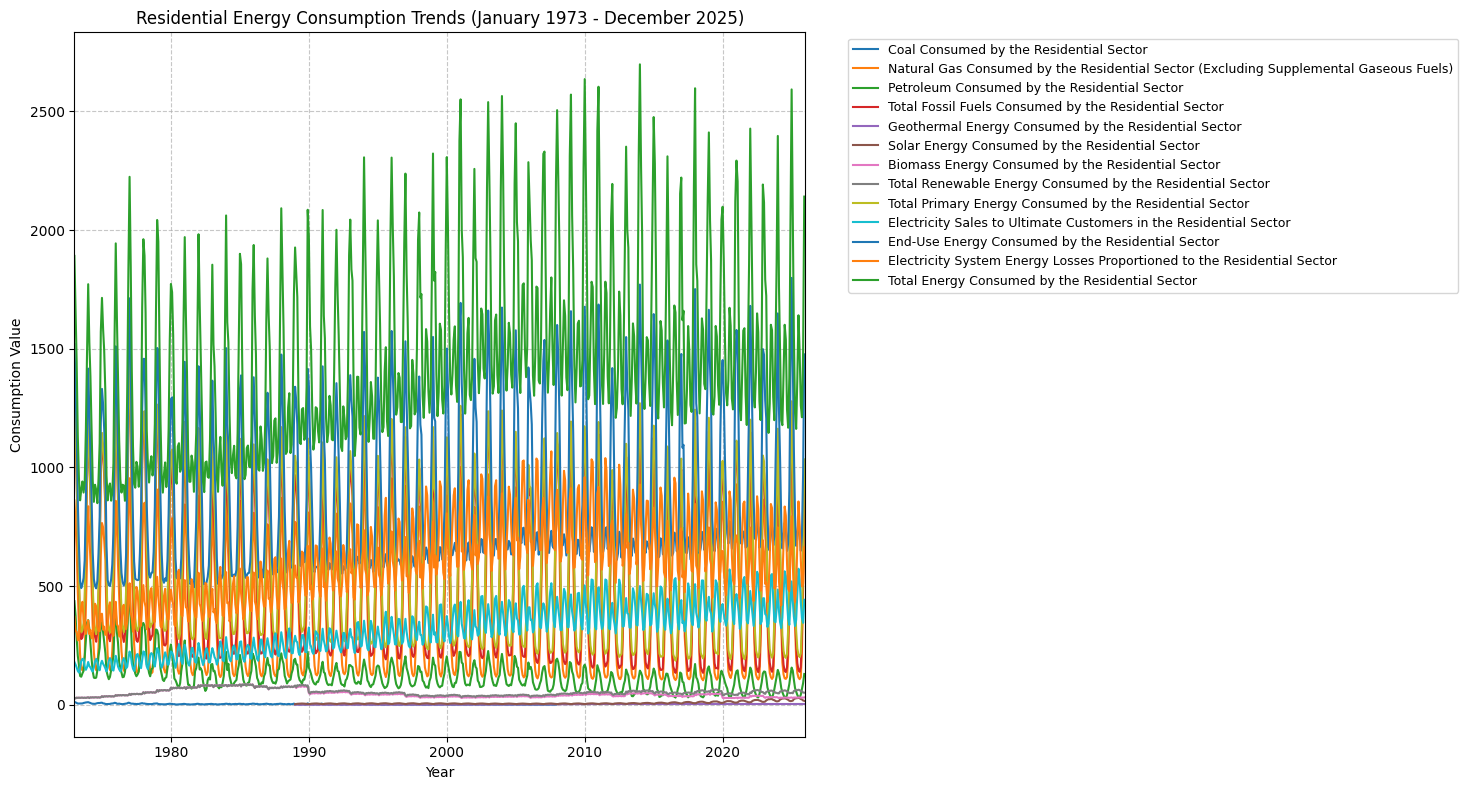

In [4]:
df.index = pd.to_datetime(df.index)
df = df.replace('Not Available', np.nan).apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(15, 8))

for column in df.columns:
    plt.plot(df.index, df[column], label=column, linewidth=1.5)

plt.title('Residential Energy Consumption Trends (January 1973 - December 2025)')
plt.xlabel('Year')
plt.ylabel('Consumption Value')
plt.xlim(pd.Timestamp('1973-01-01'), pd.Timestamp('2025-12-31'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### #2 Split the dataset into training and validation sets. Use data from January 1973 to December 2021 as the training set and January 2022 to December 2025 as the validation set. Clearly specify the date ranges. 

In [5]:
split_date = '2021-12-31'
train_df = df.loc[:split_date]
val_df = df.loc['2022-01-01':]

print(f"Training Set Range: {train_df.index.min().date()} to {train_df.index.max().date()}")
print(f"Validation Set Range: {val_df.index.min().date()} to {val_df.index.max().date()}")
print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Training Set Range: 1973-01-01 to 2021-12-01
Validation Set Range: 2022-01-01 to 2025-12-01

Training samples: 588
Validation samples: 48


In [6]:
#Prep method 
target_col = 'Total Energy Consumed by the Residential Sector'
train_series = train_df[target_col]
val_series = val_df[target_col]

t_train = np.arange(len(train_series)).reshape(-1, 1)
t_val = np.arange(len(train_series), len(train_series) + len(val_series)).reshape(-1, 1)

def model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100 # Convert to percentage
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print(f"R²:   {r2:.4f}")
    print("-" * 30)

    plt.figure(figsize=(10, 3))
    plt.plot(val_series.index, y_true, label='Actual', color='black')
    plt.plot(val_series.index, y_pred, label='Forecast', color='red', linestyle='--')
    plt.title(f"{model_name} Forecast")
    plt.legend()
    plt.show()

### #3 Linear Trend

--- Linear Trend Model Performance ---
MAE:  381.2286
RMSE: 428.7154
MAPE: 26.6013%
R²:   -0.3464
------------------------------


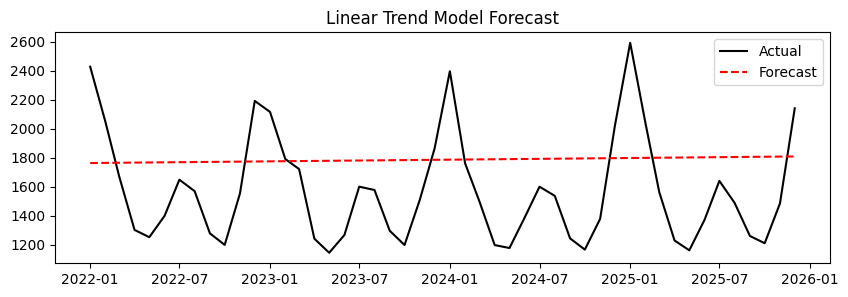

In [7]:
model_linear = LinearRegression()
model_linear.fit(t_train, train_series)
pred_linear = model_linear.predict(t_val)
model(val_series, pred_linear, "Linear Trend Model")

### #3 Additive Seasonality model

--- Additive Seasonality Model Performance ---
MAE:  222.8825
RMSE: 250.8191
MAPE: 15.5031%
R²:   0.5392
------------------------------


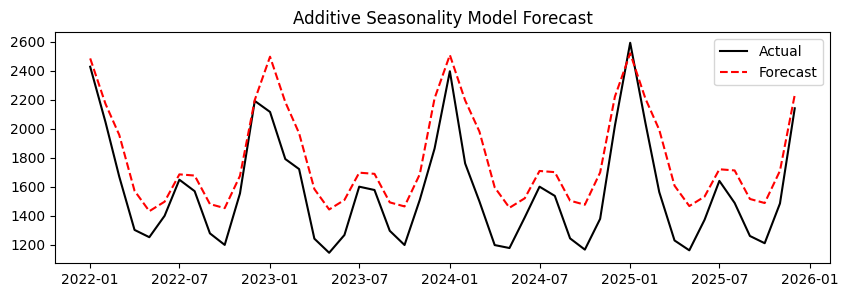

In [8]:
train_months = pd.get_dummies(train_series.index.month, prefix='month', drop_first=True)
X_train_seasonal = np.hstack([t_train, train_months.values])

val_months = pd.get_dummies(val_series.index.month, prefix='month', drop_first=True)
X_val_seasonal = np.hstack([t_val, val_months.values])

model_seasonal = LinearRegression()
model_seasonal.fit(X_train_seasonal, train_series)
pred_seasonal = model_seasonal.predict(X_val_seasonal)
model(val_series, pred_seasonal, "Additive Seasonality Model")

### #3 Quadratic Trend and Seasonality

--- Quadratic Trend & Seasonality Model Performance ---
MAE:  111.3355
RMSE: 140.0311
MAPE: 7.5010%
R²:   0.8564
------------------------------


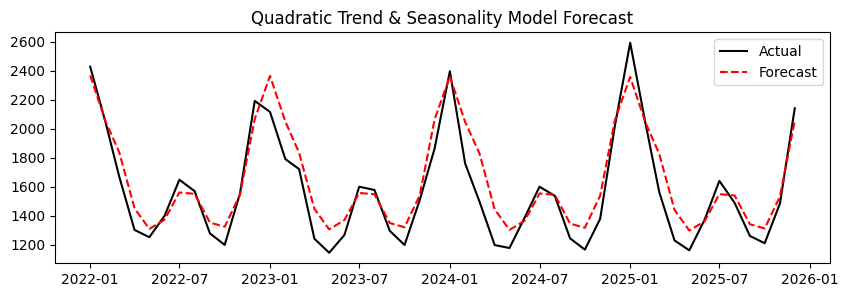

In [9]:
t_train_sq = t_train**2
t_val_sq = t_val**2

train_months = pd.get_dummies(train_series.index.month, prefix='month', drop_first=True)
val_months = pd.get_dummies(val_series.index.month, prefix='month', drop_first=True)

X_train_quad = np.hstack([t_train, t_train_sq, train_months.values])
X_val_quad = np.hstack([t_val, t_val_sq, val_months.values])

model_quad = LinearRegression()
model_quad.fit(X_train_quad, train_series)
pred_quad = model_quad.predict(X_val_quad)
model(val_series, pred_quad, "Quadratic Trend & Seasonality Model")

### #3 Simple Exponential Smoothing

c:\Users\tobia\OneDrive\Desktop\School\EIA_Residential_Energy_Consumption_Time_Series_Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


--- Simple Exponential Smoothing (SES) Performance ---
MAE:  420.7809
RMSE: 466.1999
MAPE: 29.8323%
R²:   -0.5921
------------------------------


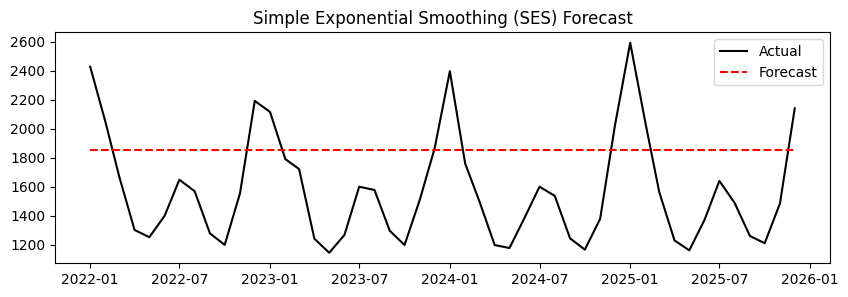

In [10]:
model_ses = SimpleExpSmoothing(train_series, initialization_method="estimated").fit()
pred_ses = model_ses.forecast(len(val_series))
model(val_series, pred_ses, "Simple Exponential Smoothing (SES)")

### #5 Create plots for each of the four models showing actual vs. forecasted values. Use distinct colors and legends to differentiate training, validation, and forecasted data. 

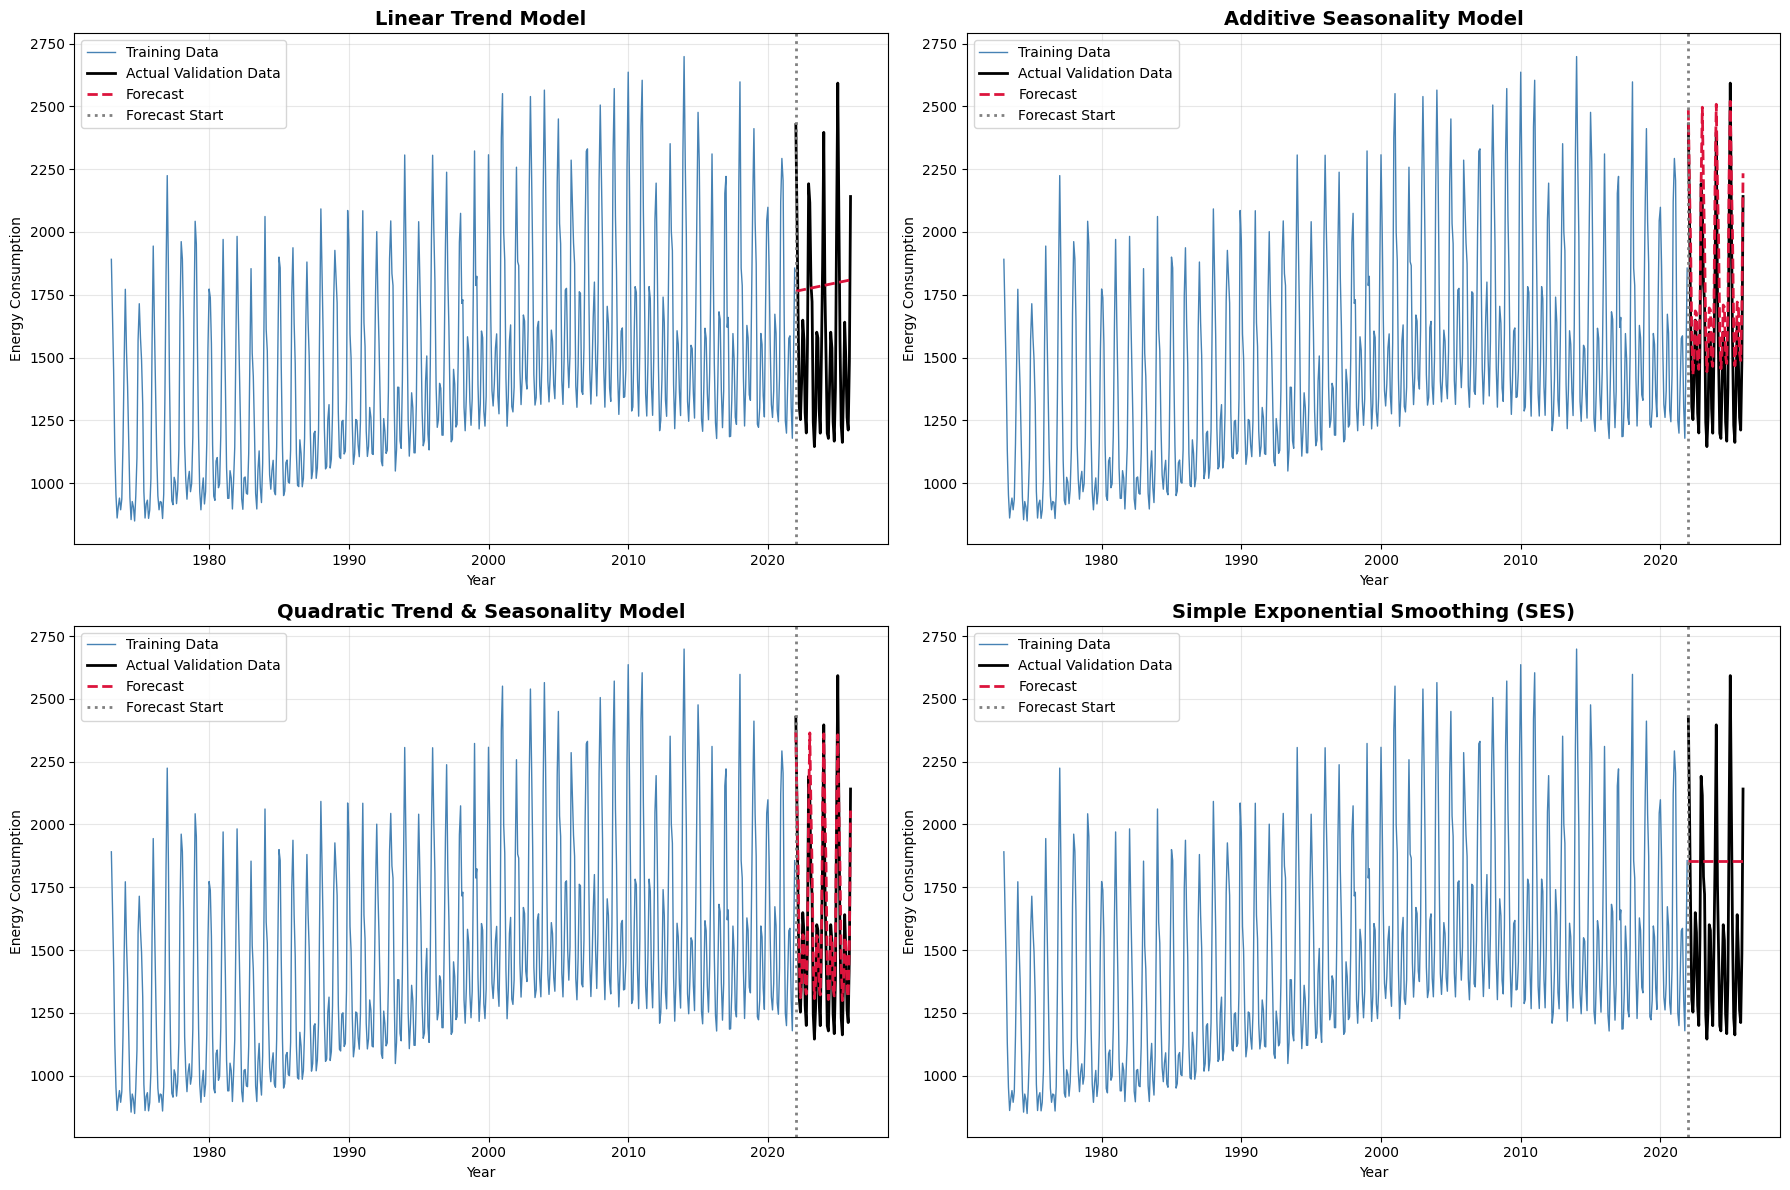

In [11]:
models_data = [("Linear Trend Model", pred_linear), ("Additive Seasonality Model", pred_seasonal), ("Quadratic Trend & Seasonality Model", pred_quad), ("Simple Exponential Smoothing (SES)", pred_ses)]
fig, axes = plt.subplots(2, 2, figsize=(18, 12)) #set all 4 graphs together in a 2x2 grid
axes = axes.flatten()

split_date = pd.Timestamp('2021-12-31')

for i, (name, pred) in enumerate(models_data):
    ax = axes[i]
    ax.plot(train_series.index, train_series, color='steelblue', label='Training Data', linewidth=1)
    ax.plot(val_series.index, val_series, color='black', label='Actual Validation Data', linewidth=2)
    ax.plot(val_series.index, pred, color='crimson', label='Forecast', linewidth=2, linestyle='--')
    ax.axvline(x=split_date, color='gray', linestyle=':', linewidth=2, label='Forecast Start') #line to separate forecast and training data
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Energy Consumption')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3) 

plt.tight_layout()
plt.show()

### #6 Report the alpha (smoothing) value used for the SES model. 

In [12]:
#SES retrieval since i used .fit for optimal alpha
alpha = model_ses.params['smoothing_level']
print(f"{alpha:.4f}")

1.0000


### #7 Select any 12 consecutive months and create a table

In [13]:
target_col = 'Electricity Sales to Ultimate Customers in the Residential Sector'
series = df[target_col]
sma_forecast = series.rolling(window=6).mean().shift(1)
model_es = SimpleExpSmoothing(series, initialization_method="estimated").fit(smoothing_level=0.2) #alpha of 0.2
es_forecast = model_es.predict(start=0, end=len(series)-1).shift(1)

results_df = pd.DataFrame({'Actual Sales': series, '6-Month SMA Forecast': sma_forecast, 'Exponential Smoothing Forecast': es_forecast})

final_table = results_df.loc['2020-01-01':'2020-12-01']
print(final_table)

            Actual Sales  6-Month SMA Forecast  Exponential Smoothing Forecast
2020-01-01       424.597            436.125500                      408.284603
2020-02-01       382.563            419.459833                      409.251282
2020-03-01       355.718            397.873167                      412.320426
2020-04-01       333.554            382.341833                      406.368941
2020-05-01       360.583            376.519833                      396.238752
2020-06-01       448.808            378.355500                      383.701802
2020-07-01       570.173            384.303833                      379.078042
2020-08-01       542.300            408.566500                      393.024033
2020-09-01       436.135            435.189333                      428.453827
2020-10-01       360.014            448.592167                      451.223061
2020-11-01       340.043            453.002167                      448.205449
2020-12-01       442.744            449.578833      

c:\Users\tobia\OneDrive\Desktop\School\EIA_Residential_Energy_Consumption_Time_Series_Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


c:\Users\tobia\OneDrive\Desktop\School\EIA_Residential_Energy_Consumption_Time_Series_Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\tobia\OneDrive\Desktop\School\EIA_Residential_Energy_Consumption_Time_Series_Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


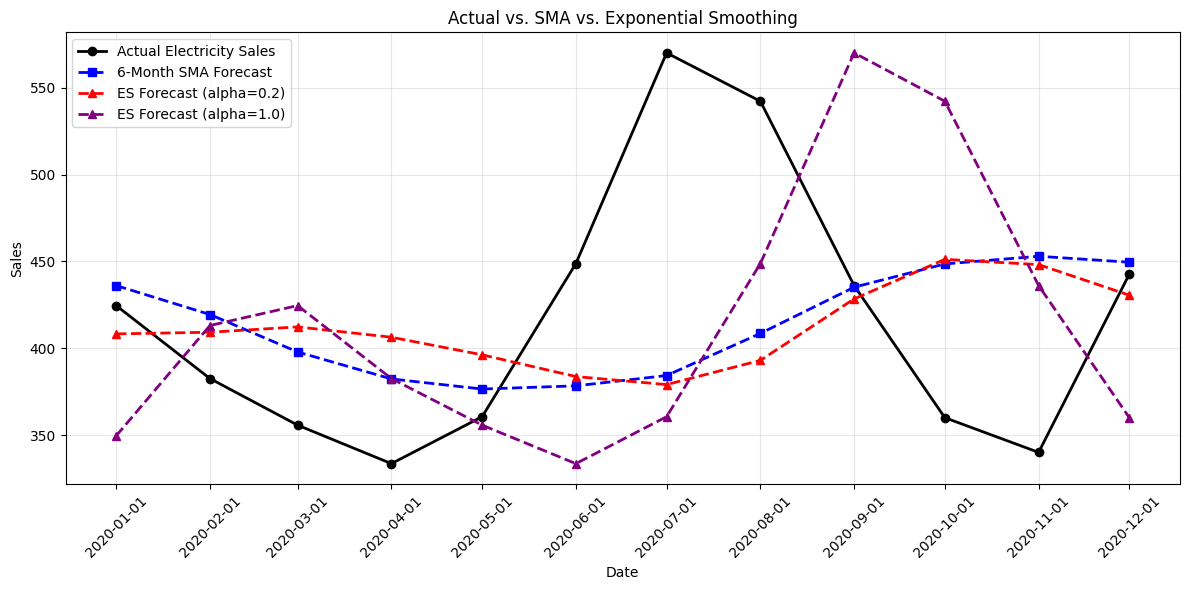

In [14]:
target_col = 'Electricity Sales to Ultimate Customers in the Residential Sector'
series = df[target_col]

sma_forecast = series.rolling(window=6).mean().shift(1)
model_es_alpha_0_2 = SimpleExpSmoothing(series, initialization_method="estimated").fit(smoothing_level=0.2)
es_forecast_0_2 = model_es_alpha_0_2.predict(start=0, end=len(series)-1).shift(1)
model_es_alpha_1_0 = SimpleExpSmoothing(series, initialization_method="estimated").fit(smoothing_level=1)
es_forecast_1_0 = model_es_alpha_1_0.predict(start=0, end=len(series)-1).shift(1)

results_df = pd.DataFrame({'Actual': series, 'SMA': sma_forecast, 'ES_Alpha_0.2': es_forecast_0_2, 'ES_Alpha_1': es_forecast_1_0})
plot_df = results_df.loc['2020-01-01':'2020-12-01']

plt.figure(figsize=(12, 6))
plt.plot(plot_df.index, plot_df['Actual'], color='black', marker='o', linewidth=2, label='Actual Electricity Sales')
plt.plot(plot_df.index, plot_df['SMA'], color='blue', linestyle='--', marker='s', linewidth=2, label='6-Month SMA Forecast')
plt.plot(plot_df.index, plot_df['ES_Alpha_0.2'], color='red', linestyle='--', marker='^', linewidth=2, label='ES Forecast (alpha=0.2)')
plt.plot(plot_df.index, plot_df['ES_Alpha_1'], color='purple', linestyle='--', marker='^', linewidth=2, label='ES Forecast (alpha=1.0)')

plt.title('Actual vs. SMA vs. Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(plot_df.index, rotation=45)
plt.tight_layout()
plt.show()

### #8 Build and run a SARIMA model using the training dataset. Justify parameter selection (p, d, q, P, D, Q, m) using ACF/PACF or AIC. Plot actual vs. forecasted values 

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=6854.271, Time=2.44 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=7187.156, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=6976.389, Time=1.68 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=6886.710, Time=1.57 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=7187.737, Time=0.07 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=7059.702, Time=0.19 sec
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=6853.326, Time=2.81 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=6977.251, Time=2.24 sec
 ARIMA(1,0,1)(2,1,1)[12] intercept   : AIC=6842.364, Time=5.61 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=6899.947, Time=4.02 sec
 ARIMA(1,0,1)(2,1,2)[12] intercept   : AIC=6841.048, Time=7.17 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=inf, Time=2.96 sec
 ARIMA(0,0,1)(2,1,2)[12] intercept   : AIC=6870.823, Time=2.80 sec
 ARIMA(1,0,0)(2,1,2)[12] intercept   : AIC=6839.930, Time=2.64 sec
 ARIMA(1,0,0)(1,1,2)[12]

c:\Users\tobia\OneDrive\Desktop\School\EIA_Residential_Energy_Consumption_Time_Series_Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\tobia\OneDrive\Desktop\School\EIA_Residential_Energy_Consumption_Time_Series_Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


MAE:77.9812
RMSE:102.9079
MAPE:4.7379%
R²:0.9224


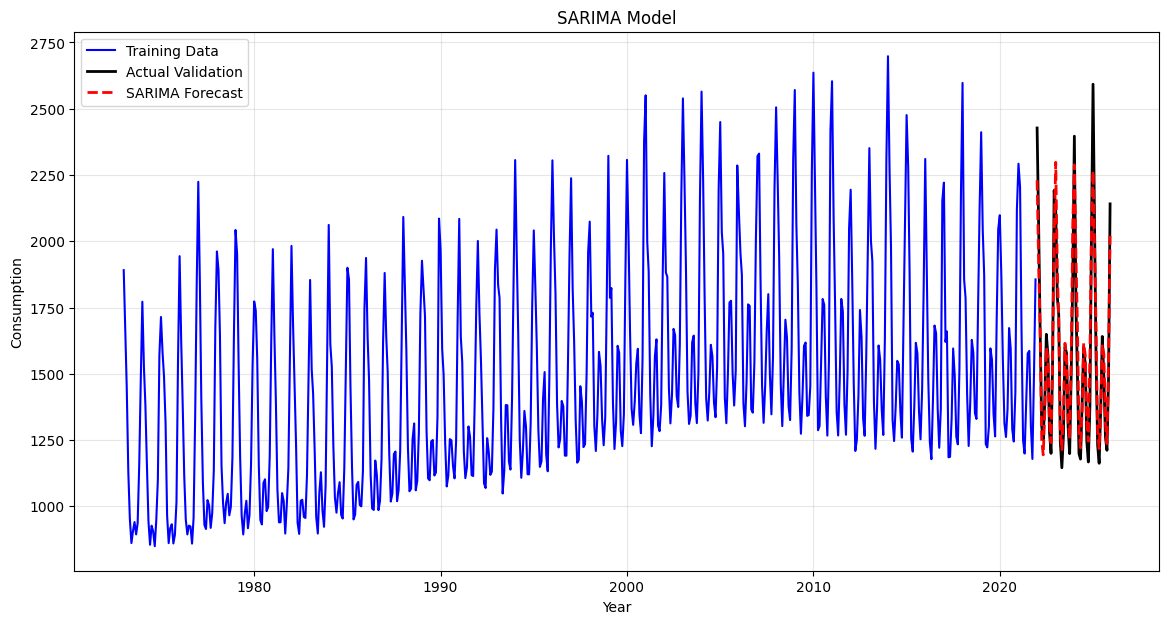

In [15]:
target_col = 'Total Energy Consumed by the Residential Sector'
train_series = train_df[target_col]
val_series = val_df[target_col]

stepwise_model = auto_arima(train_series, 
                            start_p=1, # optimizer starts at 1 and optimizer will test values up to max_p and choose best p based on AIC
                            start_q=1, # initial order of the MA component; the optimizer will test values from here up to max_q
                            max_p=3, # reasonable range to stop overfitting
                            max_q=3, # reasonable range to stop overfitting
                            m=12, #set to 12 because the dataset is monthly and we expect yearly seasonality
                            start_P=0, # starting order for the seasonal auto regressive component
                            seasonal=True, # enable seasonal components to upgrade the model from ARIMA to SARIMA
                            d=None, # non seasonal differencing set to None to let the algorithm automatically determine the best value via unit root tests
                            D=1, # seasonal differencing set to 1 to remove the seasonal trend and make the series stationary
                            trace=True, 
                            error_action='ignore', 
                            suppress_warnings=True, 
                            stepwise=True)

order = stepwise_model.order #(p,d,q)
seasonal_order = stepwise_model.seasonal_order #(P,D,Q,m)
print(f"\nBest Model Order: {order}")
print(f"Best Seasonal Order: {seasonal_order}")

model_sarima = SARIMAX(train_series, 
                      order=order, 
                      seasonal_order=seasonal_order, 
                      enforce_stationarity=False, 
                      enforce_invertibility=False)
results_sarima = model_sarima.fit()

# forecast into the Validation Period
forecast_steps = len(val_series)
pred_sarima = results_sarima.get_forecast(steps=forecast_steps).predicted_mean

mae = mean_absolute_error(val_series, pred_sarima)
rmse = np.sqrt(mean_squared_error(val_series, pred_sarima))
mape = mean_absolute_percentage_error(val_series, pred_sarima) * 100
r2 = r2_score(val_series, pred_sarima)

print(f"MAE:{mae:.4f}")
print(f"RMSE:{rmse:.4f}")
print(f"MAPE:{mape:.4f}%")
print(f"R²:{r2:.4f}")

plt.figure(figsize=(14, 7))
plt.plot(train_series.index, train_series, label='Training Data', color='blue')
plt.plot(val_series.index, val_series, label='Actual Validation', color='black', linewidth=2)
plt.plot(val_series.index, pred_sarima, label='SARIMA Forecast', color='red', linestyle='--', linewidth=2)
plt.title('SARIMA Model')
plt.xlabel('Year')
plt.ylabel('Consumption')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### #10 Take the residuals (forecast errors) from your best model and plot them. Identify the two largest "errors" in your validation set. 

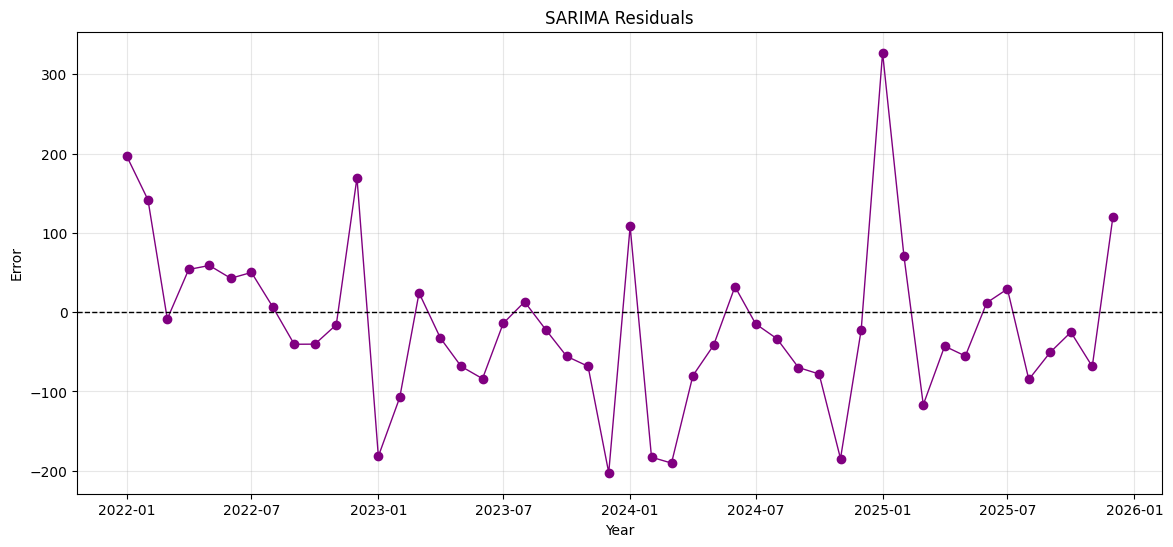

top 2 largest errors
date: 2025-01-01 | error: 327.0949 | under predicted
date: 2023-12-01 | error: -202.5280 | over predicted


In [16]:
residuals = val_series - pred_sarima
plt.figure(figsize=(14, 6))
plt.plot(residuals.index, residuals, color='purple', marker='o', linestyle='-', linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('SARIMA Residuals')
plt.xlabel('Year')
plt.ylabel('Error')
plt.grid(True, alpha=0.3)
plt.show()

largest_errors = residuals.abs().sort_values(ascending=False).head(2)

print("top 2 largest errors")
for date, value in largest_errors.items():   
    actual_err = residuals.loc[date]
    error_type = "under predicted" if actual_err > 0 else "over predicted"
    print(f"date: {date.date()} | error: {actual_err:.4f} | {error_type}")